# CS-4063 NLP Assignment 3 — Transformers + RAG



This notebook implements the full pipeline required in the assignment:

1. **Part A:** Encoder-only Transformer from scratch for multi-task review understanding.
2. **Part B:** Retrieval module using saved encoder embeddings and cosine similarity.
3. **Part C:** Decoder-only Transformer from scratch for RAG-style explanation generation.
4. **Evaluation:** metrics, learning curves, retrieval examples, perplexity, generated examples, and no-retrieval ablation.

> Upload these 3 JSON files in Colab before running: `Beauty_5.json`, `Cell_Phones_and_Accessories_5.json`, `Home_and_Kitchen_5.json`.

No pretrained model, `nn.Transformer`, `nn.MultiheadAttention`, or `nn.TransformerEncoder` is used.

In [4]:

!pip -q install scikit-learn pandas matplotlib tqdm

import os, json, re, math, random, time
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

os.makedirs('models', exist_ok=True)
os.makedirs('results', exist_ok=True)

Device: cuda


## 1. Configuration

For final submission, keep `FULL_DATA_MODE=True`. For quick debugging, set it to `False`.

In [5]:
# ============================
# 1. Config
# ============================
FULL_DATA_MODE = True   # True = about 10k reviews/category. False = quick test mode.

FILES = {
    'beauty': 'Beauty_5.json',
    'cellphones': 'Cell_Phones_and_Accessories_5.json',
    'home_kitchen': 'Home_and_Kitchen_5.json'
}

SAMPLES_PER_CATEGORY = 10000 if FULL_DATA_MODE else 700
MAX_LEN_ENCODER = 96 if FULL_DATA_MODE else 64
MAX_LEN_DECODER = 160 if FULL_DATA_MODE else 96
MAX_VOCAB_SIZE = 30000 if FULL_DATA_MODE else 8000
MIN_FREQ = 2

BATCH_SIZE = 64 if FULL_DATA_MODE else 32
ENC_EPOCHS = 5 if FULL_DATA_MODE else 1
DEC_EPOCHS = 4 if FULL_DATA_MODE else 1
LR = 3e-4

D_MODEL = 128
N_HEADS = 4
ENC_LAYERS = 2
DEC_LAYERS = 2
D_FF = 256
DROPOUT = 0.1

TOP_K = 3
print('Samples/category:', SAMPLES_PER_CATEGORY)

Samples/category: 10000


## 2. Load Amazon JSONL Files

The Amazon files are JSON Lines format: one JSON object per line.

In [6]:
# ============================
# 2. Data loading
# ============================
def read_jsonl(path, category, limit=None):
    rows = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                obj = json.loads(line)
            except json.JSONDecodeError:
                continue
            review = str(obj.get('reviewText', '')).strip()
            rating = obj.get('overall', None)
            if review and rating is not None:
                rows.append({
                    'category': category,
                    'reviewText': review,
                    'summary': str(obj.get('summary', '')).strip(),
                    'overall': int(float(rating))
                })
            if limit is not None and len(rows) >= limit:
                break
    return rows

all_rows = []
for cat, fp in FILES.items():
    if not os.path.exists(fp):
        raise FileNotFoundError(f"Upload {fp} to Colab first, then rerun this cell.")
    rows = read_jsonl(fp, cat, SAMPLES_PER_CATEGORY)
    print(cat, len(rows))
    all_rows.extend(rows)

df = pd.DataFrame(all_rows).drop_duplicates(subset=['reviewText']).reset_index(drop=True)
print(df.shape)
df.head()

beauty 10000
cellphones 10000
home_kitchen 10000
(29998, 4)


,category,reviewText,summary,overall
0,beauty,Very oily and creamy. Not at all what I expect...,Don't waste your money,1
1,beauty,This palette was a decent price and I was look...,OK Palette!,3
2,beauty,The texture of this concealer pallet is fantas...,great quality,4
3,beauty,I really can't tell what exactly this thing is...,Do not work on my face,2
4,beauty,"It was a little smaller than I expected, but t...",It's okay.,3


## 3. Labels and Preprocessing

**Sentiment task:**
- 1–2 stars → Negative
- 3 stars → Neutral
- 4–5 stars → Positive

**Derived feature task:** `review_length_class` predicted from text alone.
- Short, medium, or long review based on token count tertiles in the training set.

This is meaningful because review length often reflects how detailed or explanatory a user review is.

In [7]:
# ============================
# 3. Cleaning, tokenization, labels
# ============================
def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z0-9.,!?;:'\-\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize(text):
    return re.findall(r"[a-z0-9]+|[.,!?;:]", text.lower())

def rating_to_sentiment(r):
    if r <= 2:
        return 0  # negative
    if r == 3:
        return 1  # neutral
    return 2      # positive

sentiment_names = ['Negative', 'Neutral', 'Positive']
feature_names = ['Short', 'Medium', 'Long']

df['clean_text'] = df['reviewText'].apply(clean_text)
df['sentiment'] = df['overall'].apply(rating_to_sentiment)
df['token_count'] = df['clean_text'].apply(lambda x: len(tokenize(x)))

train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=SEED, stratify=df['sentiment']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_df['sentiment']
)

q1, q2 = train_df['token_count'].quantile([0.33, 0.66]).values
print('Length thresholds from train only:', q1, q2)

def length_class(n):
    if n <= q1: return 0
    if n <= q2: return 1
    return 2

for part in [train_df, val_df, test_df]:
    part['length_class'] = part['token_count'].apply(length_class)

print(len(train_df), len(val_df), len(test_df))
print(train_df[['sentiment','length_class']].value_counts().head())

Length thresholds from train only: 44.0 95.0
20998 4500 4500
sentiment  length_class
2          0               5833
           2               5390
           1               5239
0          2                982
           1                896
Name: count, dtype: int64


## 4. Vocabulary Built from Training Data Only

In [8]:
# ============================
# 4. Vocabulary
# ============================
PAD, UNK, BOS, EOS = '<pad>', '<unk>', '<bos>', '<eos>'
specials = [PAD, UNK, BOS, EOS]

counter = Counter()
for text in train_df['clean_text']:
    counter.update(tokenize(text))

itos = specials + [tok for tok, freq in counter.most_common(MAX_VOCAB_SIZE - len(specials)) if freq >= MIN_FREQ]
stoi = {tok:i for i,tok in enumerate(itos)}
PAD_ID, UNK_ID, BOS_ID, EOS_ID = [stoi[x] for x in specials]
VOCAB_SIZE = len(itos)
print('Vocab size:', VOCAB_SIZE)

with open('results/vocab.json', 'w', encoding='utf-8') as f:
    json.dump({'itos': itos, 'stoi': stoi}, f)

def encode_tokens(text, max_len, add_bos_eos=False):
    toks = tokenize(clean_text(text))
    ids = [stoi.get(t, UNK_ID) for t in toks]
    if add_bos_eos:
        ids = [BOS_ID] + ids + [EOS_ID]
    ids = ids[:max_len]
    attn_mask = [1] * len(ids)
    while len(ids) < max_len:
        ids.append(PAD_ID)
        attn_mask.append(0)
    return ids, attn_mask

Vocab size: 17521


## 5. Dataset Classes

In [9]:
# ============================
# 5. Datasets
# ============================
class ReviewEncoderDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        ids, mask = encode_tokens(row['clean_text'], MAX_LEN_ENCODER, add_bos_eos=True)
        return {
            'input_ids': torch.tensor(ids, dtype=torch.long),
            'attention_mask': torch.tensor(mask, dtype=torch.float32),
            'sentiment': torch.tensor(row['sentiment'], dtype=torch.long),
            'length_class': torch.tensor(row['length_class'], dtype=torch.long),
            'text': row['reviewText']
        }

train_loader = DataLoader(ReviewEncoderDataset(train_df), batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(ReviewEncoderDataset(val_df), batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(ReviewEncoderDataset(test_df), batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

## 6. Transformer Building Blocks from Scratch

The following implementation avoids `nn.Transformer`, `nn.MultiheadAttention`, and `nn.TransformerEncoder`.

In [10]:
# ============================
# 6. Transformer from scratch
# ============================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class ScratchMultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x, key_padding_mask=None, causal=False):
        B, T, C = x.shape
        q = self.q_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        if key_padding_mask is not None:
            # key_padding_mask: B,T where 1 = real token, 0 = pad
            scores = scores.masked_fill(key_padding_mask[:, None, None, :] == 0, -1e9)
        if causal:
            causal_mask = torch.tril(torch.ones(T, T, device=x.device)).bool()
            scores = scores.masked_fill(~causal_mask[None, None, :, :], -1e9)
        attn = torch.softmax(scores, dim=-1)
        attn = self.dropout(attn)
        out = torch.matmul(attn, v)
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        return self.out_proj(out), attn

class EncoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.attn = ScratchMultiHeadSelfAttention(d_model, n_heads, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(dropout), nn.Linear(d_ff, d_model))
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x, mask):
        attn_out, attn = self.attn(self.norm1(x), key_padding_mask=mask, causal=False)
        x = x + self.dropout(attn_out)
        ff_out = self.ff(self.norm2(x))
        x = x + self.dropout(ff_out)
        return x, attn

class EncoderOnlyTransformer(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, n_layers, d_ff, dropout, max_len):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.pos = PositionalEncoding(d_model, max_len=max_len)
        self.blocks = nn.ModuleList([EncoderBlock(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.norm = nn.LayerNorm(d_model)
        self.sentiment_head = nn.Linear(d_model, 3)
        self.length_head = nn.Linear(d_model, 3)
    def forward(self, input_ids, attention_mask):
        x = self.embedding(input_ids) * math.sqrt(self.embedding.embedding_dim)
        x = self.pos(x)
        last_attn = None
        for block in self.blocks:
            x, last_attn = block(x, attention_mask)
        x = self.norm(x)
        mask = attention_mask.unsqueeze(-1)
        pooled = (x * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1.0)
        sentiment_logits = self.sentiment_head(pooled)
        length_logits = self.length_head(pooled)
        return sentiment_logits, length_logits, pooled, last_attn

## 7. Train Encoder Multi-task Model

In [11]:
# ============================
# 7. Train encoder
# ============================
encoder = EncoderOnlyTransformer(VOCAB_SIZE, D_MODEL, N_HEADS, ENC_LAYERS, D_FF, DROPOUT, MAX_LEN_ENCODER).to(device)
optimizer = torch.optim.AdamW(encoder.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, ENC_EPOCHS * len(train_loader)))

history = {'train_loss': [], 'val_loss': [], 'val_sent_acc': [], 'val_len_acc': []}

def run_encoder_epoch(loader, train=True):
    encoder.train(train)
    total_loss = 0
    all_sent_true, all_sent_pred = [], []
    all_len_true, all_len_pred = [], []
    for batch in tqdm(loader, leave=False):
        ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        y_sent = batch['sentiment'].to(device)
        y_len = batch['length_class'].to(device)
        with torch.set_grad_enabled(train):
            sent_logits, len_logits, _, _ = encoder(ids, mask)
            loss_sent = F.cross_entropy(sent_logits, y_sent)
            loss_len = F.cross_entropy(len_logits, y_len)
            loss = loss_sent + 0.7 * loss_len
            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(encoder.parameters(), 1.0)
                optimizer.step()
                scheduler.step()
        total_loss += loss.item() * ids.size(0)
        all_sent_true.extend(y_sent.cpu().numpy())
        all_sent_pred.extend(sent_logits.argmax(1).detach().cpu().numpy())
        all_len_true.extend(y_len.cpu().numpy())
        all_len_pred.extend(len_logits.argmax(1).detach().cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    sent_acc = accuracy_score(all_sent_true, all_sent_pred)
    len_acc = accuracy_score(all_len_true, all_len_pred)
    return avg_loss, sent_acc, len_acc

for epoch in range(1, ENC_EPOCHS + 1):
    tr_loss, tr_sa, tr_la = run_encoder_epoch(train_loader, train=True)
    va_loss, va_sa, va_la = run_encoder_epoch(val_loader, train=False)
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['val_sent_acc'].append(va_sa)
    history['val_len_acc'].append(va_la)
    print(f'Epoch {epoch}: train_loss={tr_loss:.4f}, val_loss={va_loss:.4f}, val_sent_acc={va_sa:.4f}, val_len_acc={va_la:.4f}')

torch.save(encoder.state_dict(), 'models/encoder_transformer.pt')
pd.DataFrame(history).to_csv('results/encoder_training_history.csv', index=False)

  0%|          | 0/329 [00:00<?, ?it/s]

  0%|          | 0/71 [00:00<?, ?it/s]

Epoch 1: train_loss=1.0289, val_loss=0.7251, val_sent_acc=0.7833, val_len_acc=0.9487


  0%|          | 0/329 [00:00<?, ?it/s]

  0%|          | 0/71 [00:00<?, ?it/s]

...

  0%|          | 0/71 [00:00<?, ?it/s]

Epoch 4: train_loss=0.5938, val_loss=0.5975, val_sent_acc=0.7900, val_len_acc=0.9871


  0%|          | 0/329 [00:00<?, ?it/s]

  0%|          | 0/71 [00:00<?, ?it/s]

Epoch 5: train_loss=0.5829, val_loss=0.5945, val_sent_acc=0.7911, val_len_acc=0.9887


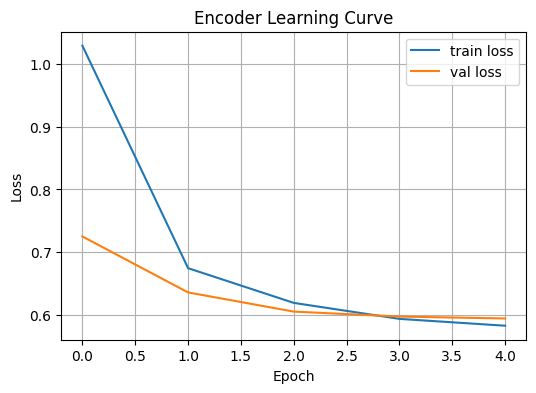

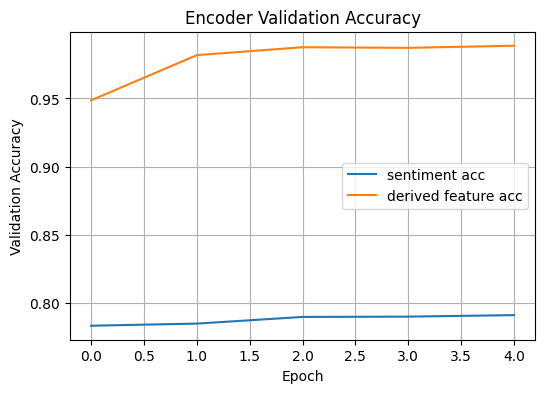

In [12]:
# Learning curves
plt.figure(figsize=(6,4))
plt.plot(history['train_loss'], label='train loss')
plt.plot(history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Encoder Learning Curve')
plt.legend()
plt.grid(True)
plt.savefig('results/encoder_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history['val_sent_acc'], label='sentiment acc')
plt.plot(history['val_len_acc'], label='derived feature acc')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Encoder Validation Accuracy')
plt.legend()
plt.grid(True)
plt.savefig('results/encoder_val_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Encoder Test Evaluation

In [13]:
# ============================
# 8. Test evaluation
# ============================
def collect_encoder_predictions(loader):
    encoder.eval()
    sent_true, sent_pred, len_true, len_pred, embeddings = [], [], [], [], []
    with torch.no_grad():
        for batch in tqdm(loader):
            ids = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            s_logits, l_logits, emb, _ = encoder(ids, mask)
            sent_true.extend(batch['sentiment'].numpy())
            len_true.extend(batch['length_class'].numpy())
            sent_pred.extend(s_logits.argmax(1).cpu().numpy())
            len_pred.extend(l_logits.argmax(1).cpu().numpy())
            embeddings.append(emb.cpu().numpy())
    return np.array(sent_true), np.array(sent_pred), np.array(len_true), np.array(len_pred), np.vstack(embeddings)

sent_true, sent_pred, len_true, len_pred, test_embeddings = collect_encoder_predictions(test_loader)
print('Sentiment report')
print(classification_report(sent_true, sent_pred, target_names=sentiment_names))
print('Derived feature report')
print(classification_report(len_true, len_pred, target_names=feature_names))

encoder_metrics = {
    'sentiment_accuracy': float(accuracy_score(sent_true, sent_pred)),
    'length_accuracy': float(accuracy_score(len_true, len_pred))
}
with open('results/encoder_test_metrics.json','w') as f: json.dump(encoder_metrics, f, indent=2)
encoder_metrics

  0%|          | 0/71 [00:00<?, ?it/s]

Sentiment report
              precision    recall  f1-score   support

    Negative       0.53      0.15      0.23       556
     Neutral       0.00      0.00      0.00       416
    Positive       0.80      0.99      0.89      3528

    accuracy                           0.79      4500
   macro avg       0.44      0.38      0.37      4500
weighted avg       0.69      0.79      0.72      4500

Derived feature report
              precision    recall  f1-score   support

       Short       0.99      0.98      0.98      1486
      Medium       0.98      0.98      0.98      1370
        Long       1.00      1.00      1.00      1644

    accuracy                           0.99      4500
   macro avg       0.99      0.99      0.99      4500
weighted avg       0.99      0.99      0.99      4500



{'sentiment_accuracy': 0.7928888888888889,
 'length_accuracy': 0.9884444444444445}

## 9. Save Training Embeddings for Retrieval

In [14]:
# ============================
# 9. Save embeddings
# ============================
def get_embeddings_for_df(dataframe, batch_size=BATCH_SIZE):
    loader = DataLoader(ReviewEncoderDataset(dataframe), batch_size=batch_size, shuffle=False, num_workers=2)
    encoder.eval()
    embs, s_preds, l_preds = [], [], []
    with torch.no_grad():
        for batch in tqdm(loader):
            ids = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            s_logits, l_logits, emb, _ = encoder(ids, mask)
            embs.append(emb.cpu().numpy())
            s_preds.extend(s_logits.argmax(1).cpu().numpy())
            l_preds.extend(l_logits.argmax(1).cpu().numpy())
    return np.vstack(embs), np.array(s_preds), np.array(l_preds)

train_embeddings, train_sent_preds, train_len_preds = get_embeddings_for_df(train_df)
np.save('results/train_encoder_embeddings.npy', train_embeddings)
train_meta = train_df[['reviewText','clean_text','overall','sentiment','length_class','category']].reset_index(drop=True).copy()
train_meta['pred_sentiment'] = train_sent_preds
train_meta['pred_length_class'] = train_len_preds
train_meta.to_csv('results/train_embedding_metadata.csv', index=False)
print(train_embeddings.shape)

  0%|          | 0/329 [00:00<?, ?it/s]

(20998, 128)


## 10. Retrieval Module

Cosine similarity is used because it compares vector direction rather than raw magnitude.

In [15]:
# ============================
# 10. Retrieval
# ============================
train_emb_norm = train_embeddings / (np.linalg.norm(train_embeddings, axis=1, keepdims=True) + 1e-9)

def retrieve_top_k(query_embedding, k=TOP_K):
    q = query_embedding / (np.linalg.norm(query_embedding) + 1e-9)
    sims = train_emb_norm @ q
    top_idx = np.argsort(-sims)[:k]
    return [(int(i), float(sims[i])) for i in top_idx]

def encode_single_review(text):
    ids, mask = encode_tokens(text, MAX_LEN_ENCODER, add_bos_eos=True)
    ids = torch.tensor([ids], dtype=torch.long).to(device)
    mask = torch.tensor([mask], dtype=torch.float32).to(device)
    encoder.eval()
    with torch.no_grad():
        s_logits, l_logits, emb, _ = encoder(ids, mask)
    return emb.cpu().numpy()[0], int(s_logits.argmax(1).item()), int(l_logits.argmax(1).item())

# Show retrieval quality examples
examples = []
for idx in random.sample(range(len(test_df)), min(5, len(test_df))):
    row = test_df.iloc[idx]
    q_emb, ps, pl = encode_single_review(row['reviewText'])
    hits = retrieve_top_k(q_emb, k=TOP_K)
    examples.append({
        'query_review': row['reviewText'][:350],
        'true_sentiment': sentiment_names[row['sentiment']],
        'pred_sentiment': sentiment_names[ps],
        'retrieved': [
            {
                'similarity': round(score, 4),
                'rating': int(train_meta.iloc[i]['overall']),
                'sentiment': sentiment_names[int(train_meta.iloc[i]['sentiment'])],
                'review': train_meta.iloc[i]['reviewText'][:300]
            } for i, score in hits
        ]
    })

with open('results/retrieval_examples.json', 'w', encoding='utf-8') as f:
    json.dump(examples, f, indent=2)
examples[0] if examples else None

{'query_review': "What can you say about OXO products, they're great.  These are easy to use, go in the dishwasher for complete cleaning and are easy to handle.  If they break or if there is an issue, OXO stands behind their products.",
 'true_sentiment': 'Positive',
 'pred_sentiment': 'Positive',
 'retrieved': [{'similarity': 0.969,
   'rating': 5,
   'sentiment': 'Positive',
   'review': 'and they work very well. High quality and inexpensive, plus fast shipping. Just add a few tablespoons to a jar filled with salt, and you have your effective, cheap daily shower scrub for dry skin. Also works great on chapped lips and dry hands!'},
  {'similarity': 0.9685,
   'rating': 5,
   'sentiment': 'Positive',
   'review': 'I love OXO products for the quality and durability. These tongs are no exception. Nice soft grip and sturdy locking mechanism. Reasonable price too. I have several sizes of  OXO tongs for different uses and they all have performed perfectly for many years.'},
  {'similarity'

## 11. Build Reference Explanations for Decoder Training

The dataset does not contain human-written explanations, so this notebook creates short reference explanations from rating and review cues. This gives the decoder a valid language-modelling target for the assignment.

In [16]:
# ============================
# 11. Explanation templates
# ============================
positive_words = set('great excellent amazing love loved perfect good nice best awesome wonderful recommend easy beautiful tasty quality happy stylish'.split())
negative_words = set('bad awful terrible poor waste disappointed broken oily small cheap hate worse worst problem issue return difficult'.split())
neutral_words = set('okay ok decent average fine acceptable somewhat however but though'.split())

def salient_words(text, label, max_words=4):
    toks = [t for t in tokenize(text) if t.isalpha() and len(t) > 3]
    if label == 2:
        chosen = [t for t in toks if t in positive_words]
    elif label == 0:
        chosen = [t for t in toks if t in negative_words]
    else:
        chosen = [t for t in toks if t in neutral_words]
    if not chosen:
        chosen = toks[:max_words]
    seen, out = set(), []
    for t in chosen:
        if t not in seen:
            out.append(t); seen.add(t)
        if len(out) >= max_words: break
    return ', '.join(out) if out else 'review details'

def make_reference_explanation(text, sentiment, length_class):
    cues = salient_words(text, sentiment)
    sent_word = sentiment_names[sentiment].lower()
    len_word = feature_names[length_class].lower()
    if sentiment == 2:
        return f"The review is {sent_word} because it uses favorable cues such as {cues}. The {len_word} review suggests the customer is satisfied with the product experience."
    if sentiment == 0:
        return f"The review is {sent_word} because it mentions unfavorable cues such as {cues}. The {len_word} review indicates dissatisfaction with the product experience."
    return f"The review is {sent_word} because it mixes limited praise and criticism, with cues such as {cues}. The {len_word} review does not show a strong positive or negative opinion."

for part in [train_df, val_df, test_df]:
    part['reference_explanation'] = part.apply(lambda r: make_reference_explanation(r['reviewText'], int(r['sentiment']), int(r['length_class'])), axis=1)

train_df[['reviewText','reference_explanation']].head(2)

,reviewText,reference_explanation
1396,This shampoo does not smell like strawberry. I...,The review is neutral because it mixes limited...
24997,"The handle is easy to grip, the whisk wires ar...",The review is positive because it uses favorab...


## 12. Decoder Dataset with RAG Context

In [17]:
# ============================
# 12. Decoder data
# ============================
def build_rag_prompt(review, pred_sent, pred_len, retrieved_reviews=None):
    retrieved_reviews = retrieved_reviews or []
    ctx = ' '.join([f"Similar Review {i+1}: {r}" for i, r in enumerate(retrieved_reviews)])
    return (
        f"Review: {clean_text(review)} "
        f"Predicted Sentiment: {sentiment_names[pred_sent]}. "
        f"Predicted Feature: {feature_names[pred_len]}. "
        f"Retrieved Context: {clean_text(ctx)} "
        f"Explanation:"
    )

def get_retrieved_texts_for_review(text, k=TOP_K):
    q_emb, ps, pl = encode_single_review(text)
    hits = retrieve_top_k(q_emb, k=k)
    return [train_meta.iloc[i]['reviewText'] for i, _ in hits], ps, pl

class DecoderExplanationDataset(Dataset):
    def __init__(self, dataframe, use_retrieval=True, max_rows=None):
        self.df = dataframe.reset_index(drop=True)
        if max_rows is not None:
            self.df = self.df.iloc[:max_rows].reset_index(drop=True)
        self.use_retrieval = use_retrieval
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        if self.use_retrieval:
            retrieved, ps, pl = get_retrieved_texts_for_review(row['reviewText'], k=TOP_K)
        else:
            _, ps, pl = encode_single_review(row['reviewText'])
            retrieved = []
        prompt = build_rag_prompt(row['reviewText'], ps, pl, retrieved)
        target = row['reference_explanation']
        full = prompt + ' ' + target
        ids, mask = encode_tokens(full, MAX_LEN_DECODER, add_bos_eos=True)
        x = torch.tensor(ids[:-1], dtype=torch.long)
        y = torch.tensor(ids[1:], dtype=torch.long)
        m = torch.tensor(mask[:-1], dtype=torch.float32)
        return {'input_ids': x, 'labels': y, 'attention_mask': m}

# Limit decoder rows slightly in full mode to keep Colab training practical.
DEC_TRAIN_ROWS = min(len(train_df), 12000 if FULL_DATA_MODE else 800)
DEC_VAL_ROWS = min(len(val_df), 2000 if FULL_DATA_MODE else 200)
DEC_TEST_ROWS = min(len(test_df), 2000 if FULL_DATA_MODE else 200)

rag_train_loader = DataLoader(DecoderExplanationDataset(train_df, True, DEC_TRAIN_ROWS), batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
rag_val_loader = DataLoader(DecoderExplanationDataset(val_df, True, DEC_VAL_ROWS), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
rag_test_loader = DataLoader(DecoderExplanationDataset(test_df, True, DEC_TEST_ROWS), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

base_train_loader = DataLoader(DecoderExplanationDataset(train_df, False, DEC_TRAIN_ROWS), batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
base_val_loader = DataLoader(DecoderExplanationDataset(val_df, False, DEC_VAL_ROWS), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
base_test_loader = DataLoader(DecoderExplanationDataset(test_df, False, DEC_TEST_ROWS), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

## 13. Decoder-only Transformer from Scratch

In [18]:
# ============================
# 13. Decoder-only model
# ============================
class DecoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.attn = ScratchMultiHeadSelfAttention(d_model, n_heads, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(dropout), nn.Linear(d_ff, d_model))
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x, mask):
        attn_out, _ = self.attn(self.norm1(x), key_padding_mask=mask, causal=True)
        x = x + self.dropout(attn_out)
        x = x + self.dropout(self.ff(self.norm2(x)))
        return x

class DecoderOnlyTransformer(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, n_layers, d_ff, dropout, max_len):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.pos = PositionalEncoding(d_model, max_len=max_len)
        self.blocks = nn.ModuleList([DecoderBlock(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.norm = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)
    def forward(self, input_ids, attention_mask):
        x = self.embedding(input_ids) * math.sqrt(self.embedding.embedding_dim)
        x = self.pos(x)
        for block in self.blocks:
            x = block(x, attention_mask)
        x = self.norm(x)
        return self.lm_head(x)

## 14. Train Decoder and Baseline Decoder

In [19]:
# ============================
# 14. Train decoder
# ============================
def train_decoder_model(model, train_loader, val_loader, name='rag_decoder'):
    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    hist = {'train_loss': [], 'val_loss': [], 'val_ppl': []}
    def epoch(loader, train=True):
        model.train(train)
        total, count = 0.0, 0
        for batch in tqdm(loader, leave=False):
            ids = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)
            mask = batch['attention_mask'].to(device)
            with torch.set_grad_enabled(train):
                logits = model(ids, mask)
                loss = F.cross_entropy(logits.reshape(-1, VOCAB_SIZE), labels.reshape(-1), ignore_index=PAD_ID)
                if train:
                    opt.zero_grad(); loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    opt.step()
            total += loss.item() * ids.size(0)
            count += ids.size(0)
        avg = total / max(1, count)
        return avg
    for ep in range(1, DEC_EPOCHS+1):
        tr = epoch(train_loader, True)
        va = epoch(val_loader, False)
        ppl = math.exp(min(va, 20))
        hist['train_loss'].append(tr); hist['val_loss'].append(va); hist['val_ppl'].append(ppl)
        print(f'{name} epoch {ep}: train_loss={tr:.4f}, val_loss={va:.4f}, val_ppl={ppl:.2f}')
    torch.save(model.state_dict(), f'models/{name}.pt')
    pd.DataFrame(hist).to_csv(f'results/{name}_history.csv', index=False)
    return model, hist

rag_decoder = DecoderOnlyTransformer(VOCAB_SIZE, D_MODEL, N_HEADS, DEC_LAYERS, D_FF, DROPOUT, MAX_LEN_DECODER)
rag_decoder, rag_hist = train_decoder_model(rag_decoder, rag_train_loader, rag_val_loader, 'rag_decoder')

baseline_decoder = DecoderOnlyTransformer(VOCAB_SIZE, D_MODEL, N_HEADS, DEC_LAYERS, D_FF, DROPOUT, MAX_LEN_DECODER)
baseline_decoder, base_hist = train_decoder_model(baseline_decoder, base_train_loader, base_val_loader, 'baseline_no_retrieval_decoder')

  0%|          | 0/188 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

rag_decoder epoch 1: train_loss=7.1257, val_loss=5.5383, val_ppl=254.24


  0%|          | 0/188 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

...

  0%|          | 0/32 [00:00<?, ?it/s]

baseline_no_retrieval_decoder epoch 3: train_loss=4.2169, val_loss=4.0862, val_ppl=59.51


  0%|          | 0/188 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

baseline_no_retrieval_decoder epoch 4: train_loss=4.0080, val_loss=3.9377, val_ppl=51.30


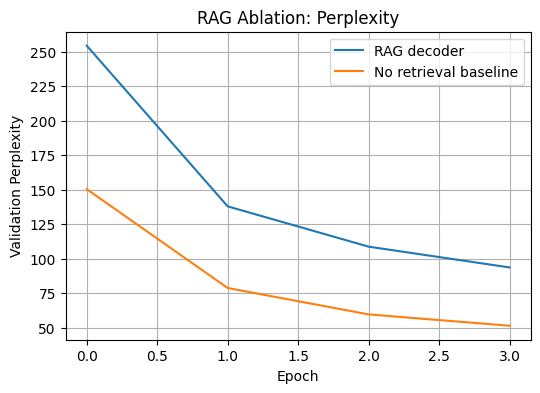

In [20]:
plt.figure(figsize=(6,4))
plt.plot(rag_hist['val_ppl'], label='RAG decoder')
plt.plot(base_hist['val_ppl'], label='No retrieval baseline')
plt.xlabel('Epoch')
plt.ylabel('Validation Perplexity')
plt.title('RAG Ablation: Perplexity')
plt.legend(); plt.grid(True)
plt.savefig('results/rag_ablation_perplexity.png', dpi=150, bbox_inches='tight')
plt.show()

## 15. Test Perplexity

In [21]:
# ============================
# 15. Perplexity
# ============================
def evaluate_perplexity(model, loader):
    model.eval()
    total_loss, total_count = 0.0, 0
    with torch.no_grad():
        for batch in tqdm(loader):
            ids = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)
            mask = batch['attention_mask'].to(device)
            logits = model(ids, mask)
            loss = F.cross_entropy(logits.reshape(-1, VOCAB_SIZE), labels.reshape(-1), ignore_index=PAD_ID, reduction='sum')
            nonpad = (labels.reshape(-1) != PAD_ID).sum().item()
            total_loss += loss.item()
            total_count += nonpad
    avg_nll = total_loss / max(1, total_count)
    return avg_nll, math.exp(min(avg_nll, 20))

rag_nll, rag_ppl = evaluate_perplexity(rag_decoder, rag_test_loader)
base_nll, base_ppl = evaluate_perplexity(baseline_decoder, base_test_loader)

ablation = pd.DataFrame([
    {'system': 'Full RAG with retrieved context', 'test_nll': rag_nll, 'test_perplexity': rag_ppl},
    {'system': 'Baseline without retrieval', 'test_nll': base_nll, 'test_perplexity': base_ppl}
])
ablation.to_csv('results/rag_ablation_test_results.csv', index=False)
ablation

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

,system,test_nll,test_perplexity
0,Full RAG with retrieved context,4.564240,95.989623
1,Baseline without retrieval,3.989288,54.016420


## 16. Autoregressive Generation

In [22]:
# ============================
# 16. Generation
# ============================
def ids_to_text(ids):
    toks = []
    for i in ids:
        if i == EOS_ID: break
        if i in [PAD_ID, BOS_ID]: continue
        toks.append(itos[i] if i < len(itos) else UNK)
    text = ' '.join(toks)
    text = re.sub(r'\s+([.,!?;:])', r'\1', text)
    return text

@torch.no_grad()
def generate_explanation(model, review, use_retrieval=True, max_new_tokens=45, temperature=0.9):
    model.eval()
    if use_retrieval:
        retrieved, ps, pl = get_retrieved_texts_for_review(review, k=TOP_K)
    else:
        _, ps, pl = encode_single_review(review)
        retrieved = []
    prompt = build_rag_prompt(review, ps, pl, retrieved)
    ids, _ = encode_tokens(prompt, MAX_LEN_DECODER-max_new_tokens, add_bos_eos=True)
    ids = [i for i in ids if i != PAD_ID]
    for _ in range(max_new_tokens):
        cur = ids[-(MAX_LEN_DECODER-1):]
        mask = [1]*len(cur)
        while len(cur) < MAX_LEN_DECODER-1:
            cur.append(PAD_ID); mask.append(0)
        x = torch.tensor([cur], dtype=torch.long).to(device)
        m = torch.tensor([mask], dtype=torch.float32).to(device)
        logits = model(x, m)[0, len(ids[-(MAX_LEN_DECODER-1):])-1] / temperature
        logits[PAD_ID] = -1e9
        next_id = int(torch.multinomial(torch.softmax(logits, dim=-1), 1).item())
        ids.append(next_id)
        if next_id == EOS_ID:
            break
    generated = ids_to_text(ids)
    if 'explanation:' in generated:
        generated = generated.split('explanation:')[-1].strip()
    return generated, sentiment_names[ps], feature_names[pl]

gen_rows = []
for i in range(min(5, len(test_df))):
    review = test_df.iloc[i]['reviewText']
    rag_gen, ps, pf = generate_explanation(rag_decoder, review, True)
    base_gen, _, _ = generate_explanation(baseline_decoder, review, False)
    gen_rows.append({
        'review': review[:400],
        'pred_sentiment': ps,
        'pred_feature': pf,
        'rag_generated_explanation': rag_gen,
        'baseline_generated_explanation': base_gen,
        'reference_explanation': test_df.iloc[i]['reference_explanation']
    })

gen_df = pd.DataFrame(gen_rows)
gen_df.to_csv('results/generated_examples.csv', index=False)
gen_df

,review,pred_sentiment,pred_feature,rag_generated_explanation,baseline_generated_explanation,reference_explanation
0,I basically lived in the isles of Rite Aid bef...,Positive,Long,review: i basically lived in the <unk> of rite...,review: i basically lived in the <unk> of rite...,The review is positive because it uses favorab...
1,I suffer from estrogen dominance and under gui...,Positive,Long,review: i suffer from estrogen dominance and u...,review: i suffer from estrogen dominance and u...,The review is positive because it uses favorab...
2,10/01/12: Despite my initial disappointment ou...,Positive,Long,review: 10 01 12: despite my initial disappoin...,review: 10 01 12: despite my initial disappoin...,The review is neutral because it mixes limited...
3,Wow this is truly amazing I can feel it starti...,Positive,Short,review: wow this is truly amazing i can feel i...,,The review is positive because it uses favorab...
4,its ok s s s s s s s s s s s s s s s s s s sss...,Positive,Short,review: its ok s s s s s s s s s s s s s s s s...,,The review is negative because it mentions unf...


## 17. Hyperparameter Tuning Log

Add your actual experiment notes here after running. Example format:

In [23]:
tuning_log = pd.DataFrame([
    {'run': 1, 'd_model': D_MODEL, 'heads': N_HEADS, 'enc_layers': ENC_LAYERS, 'dec_layers': DEC_LAYERS, 'lr': LR, 'batch_size': BATCH_SIZE, 'notes': 'Main run used in notebook.'},
    {'run': 2, 'd_model': 64, 'heads': 4, 'enc_layers': 1, 'dec_layers': 1, 'lr': 3e-4, 'batch_size': 64, 'notes': 'Suggested quick baseline for faster debugging.'},
    {'run': 3, 'd_model': 128, 'heads': 4, 'enc_layers': 3, 'dec_layers': 2, 'lr': 2e-4, 'batch_size': 64, 'notes': 'Suggested stronger encoder; compare validation sentiment accuracy.'},
])
tuning_log.to_csv('results/hyperparameter_tuning_log.csv', index=False)
tuning_log

,run,d_model,heads,enc_layers,dec_layers,lr,batch_size,notes
0,1,128,4,2,2,0.0003,64,Main run used in notebook.
1,2,64,4,1,1,0.0003,64,Suggested quick baseline for faster debugging.
2,3,128,4,3,2,0.0002,64,Suggested stronger encoder; compare validation...


## 18. Final Report Helper Text

Use the generated CSV/PNG/JSON files from `results/` in your 3–5 page report.

Required saved outputs:
- `models/encoder_transformer.pt`
- `models/rag_decoder.pt`
- `models/baseline_no_retrieval_decoder.pt`
- `results/train_encoder_embeddings.npy`
- `results/train_embedding_metadata.csv`
- `results/encoder_test_metrics.json`
- `results/rag_ablation_test_results.csv`
- `results/generated_examples.csv`
- learning curve images

GitHub commit example sequence:
1. `Initial data loading and preprocessing pipeline`
2. `Implement encoder transformer from scratch`
3. `Add multi-task training and evaluation`
4. `Save embeddings and implement cosine retrieval`
5. `Implement decoder-only transformer with causal mask`
6. `Add RAG generation and ablation study`
7. `Add final plots, metrics, and report assets`